# Execução das análises e visualização de dois experimetos de exemplo

## Clonagem do repositório do GitHub

- Clona o repositório via `git clone`
- Transfere o ambiente de execução para a pasta raiz do repositório

In [2]:
%cd /content
!git clone https://github.com/amartinsmg/classification-of-medical-images-using-cnn.git
%cd /content/classification-of-medical-images-using-cnn

/content
Cloning into 'classification-of-medical-images-using-cnn'...
remote: Enumerating objects: 753, done.
remote: Counting objects: 100% (141/141), done.
remote: Compressing objects: 100% (87/87), done.
remote: Total 753 (delta 66), reused 122 (delta 54), pack-reused 612 (from 1)
Receiving objects: 100% (753/753), 7.39 MiB | 22.71 MiB/s, done.
Resolving deltas: 100% (392/392), done.
/content/classification-of-medical-images-using-cnn


## Montagem do Google Drive

- Monta o Google Drive permitindo que os arquivos presentes nele sejam lidos e escritos
- Define o diretório base de onde serão carregados os dados de treino, validação e teste, e onde serão salvos o modelo e os resultados do experimento

In [3]:
from google.colab import drive

drive.mount("/content/drive")
RESULT_PATH = "/content/drive/MyDrive/classification-of-medical-images-using-cnn/results/"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
%cd /content/classification-of-medical-images-using-cnn
RESULT_PATH = "/content/drive/MyDrive/classification-of-medical-images-using-cnn/results/"

/content/classification-of-medical-images-using-cnn


## Carregamento dos experimentos

Carrega dos experimentos chamados:
- `example-1`
- `example-2`

In [5]:
from src.analyses import load_experiments

examples = load_experiments(RESULT_PATH, ["example-1", "example-2"])

## Visualização dos resultados dos experimentos

Visualização da tabela com média e desvio padrão para as métricas do experimento durante a fase de teste. As métricas incluem acurácia, precisão, recall (sensibilidade), score-F1, especificidade e área sob a curva ROC (AUC-ROC). A tabela é exibida usando o método `display` do IPython para uma melhor formatação.    

In [6]:
from src.analyses import metrics_table
from IPython.display import display

metrics = metrics_table(examples)
display(metrics)

,accuracy-mean,accuracy-std,precision-mean,precision-std,recall-mean,recall-std,f1-score-mean,f1-score-std,specificity-mean,specificity-std,auc-roc-mean,auc-roc-std
experiment,,,,,,,,,,,,
example-1,0.879808,0.024234,0.885167,0.056200,0.936752,0.042306,0.907570,0.013514,0.784900,0.129684,0.954208,0.005962
example-2,0.777244,0.032397,0.770897,0.046285,0.925641,0.034273,0.839279,0.015157,0.529915,0.138653,0.879663,0.003997


## Visualização dos gráficos

### Visualização das métricas do modelo durante o treinamento/validação

Para cada experimento é mostrada a média e o desvio padrão das métricas de acurácia, função de perda (loss) e área sob a curva ROC ao longo das épocas de treinamento e validação


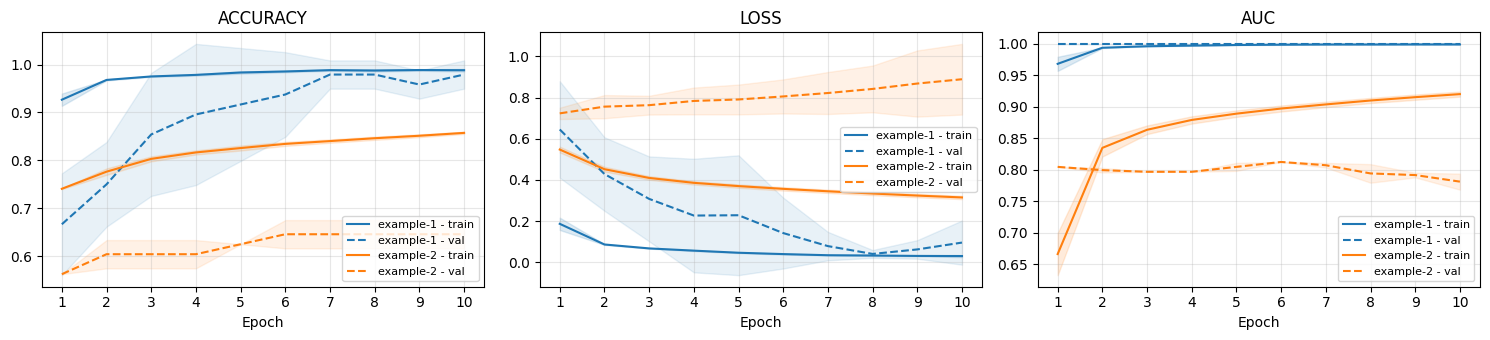

In [7]:
from src.analyses import plot_training_history
import matplotlib.pyplot as plt

fig = plot_training_history(examples)

plt.show()

### Visualização da curva ROC dos experimentos na fase de teste

Para cada experimento é plotada sua respectiva curva ROC média juntamente com o desvio padrão, permitindo a comparação visual do desempenho dos modelos em termos de sensibilidade e especificidade independente do limiar de decisão.

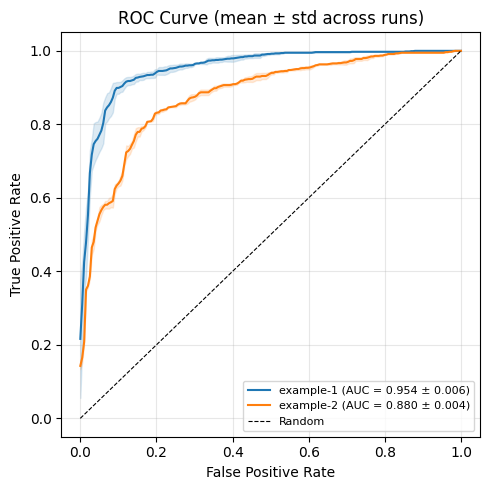

In [8]:
from src.analyses import plot_roc_curves

fig = plot_roc_curves(examples)

plt.show()

### Visualização da matriz de confusão

A matriz de confusão final é feita com a soma das rodadas do experimento, garantindo que não haja valores fracionados. A matriz é normalizada para mostrar as proporções de verdadeiros positivos, falsos positivos, verdadeiros negativos e falsos negativos, facilitando a interpretação do desempenho do modelo em cada classe.

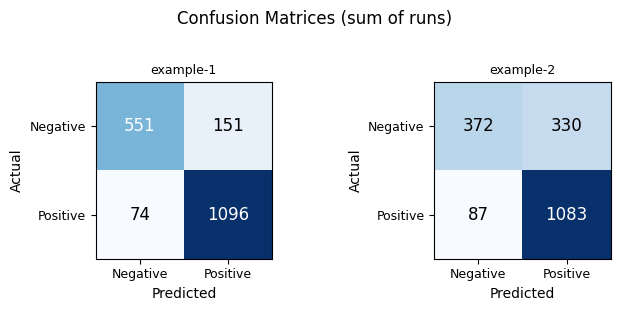

In [9]:
from src.analyses import plot_confusion_matrix

fig = plot_confusion_matrix(examples)

plt.show()

## Salvamento dos resultados da comparação dos experimentos

Salva a tabela comparativa dos experimentos em um arquivo CSV juntamente com os gráficos das comparações no Google Drive.

In [10]:
SAVE_DIR = "/content/drive/MyDrive/classification-of-medical-images-using-cnn/comparisons/example"

from src.analyses import full_comparison

_ = full_comparison(
  base_result_dir=RESULT_PATH,
  experiment_names=["example-1", "example-2"],
  show_plot=False,
  save_dir=SAVE_DIR
)


Results saved in /content/drive/MyDrive/classification-of-medical-images-using-cnn/comparisons/example
